## Depth anything based approach

This notebook uses depth anything v2 in order to estimate how well it performes for object specific depth estimation. 

Before running make sure to have followed install instructions that are in the readme file under set up.

In [1]:
# GENERAL IMPORTS
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import time
import torch
import gc
import os
import pandas as pd
from IPython.display import clear_output
from scipy import stats

import torchvision
from torchvision import transforms
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split

from utils import getDevice, collate_fn
from depth_anything_3.api import DepthAnything3
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

Using device: xpu :3
Setting seed to 42:3
[WARN ] Dependency `gsplat` is required for rendering 3DGS. Install via: pip install git+https://github.com/nerfstudio-project/gsplat.git@0b4dddf04cb687367602c01196913cde6a743d70


In [2]:
DEVICE = getDevice()
HEIGHT = 376
WIDTH = 1242
TARGET_TYPES = ['Car']
BATCH_SIZE = 4
NUM_WORKERS = 4

In [3]:
#this is a test sample to see if the code actually works mostly copied from the official website

# Load model from Hugging Face Hub
device = getDevice()
depthAnything3 = DepthAnything3.from_pretrained("depth-anything/da3metric-large")
depthAnything3 = depthAnything3.to(device=device)

# Run inference on images
images = ["../imgs/image1.jpg"]  # List of image paths, PIL Images, or numpy arrays
prediction = depthAnything3.inference(
    images
)

# Access results
print(prediction.depth.shape)        # Depth maps: [N, H, W] float32
print("intrinsics:", prediction.intrinsics)
print("extrinsics:", prediction.extrinsics)


WARNING[XFORMERS]: xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.9.1+cu128 with CUDA 1208 (you have 2.9.1+xpu)
    Python  3.10.19 (you have 3.12.13)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details


[INFO ] using MLP layer as FFN
[INFO ] Processed Images Done taking 0.037862300872802734 seconds. Shape:  torch.Size([1, 3, 504, 504])
[INFO ] Model Forward Pass Done. Time: 1.3933980464935303 seconds
[INFO ] Conversion to Prediction Done. Time: 0.0015125274658203125 seconds
(1, 504, 504)
intrinsics: None
extrinsics: None


Here we can see how a prediction looks like for a sample image. It is pixelwise. Thus we can sample any subset of the image to achieve the results.

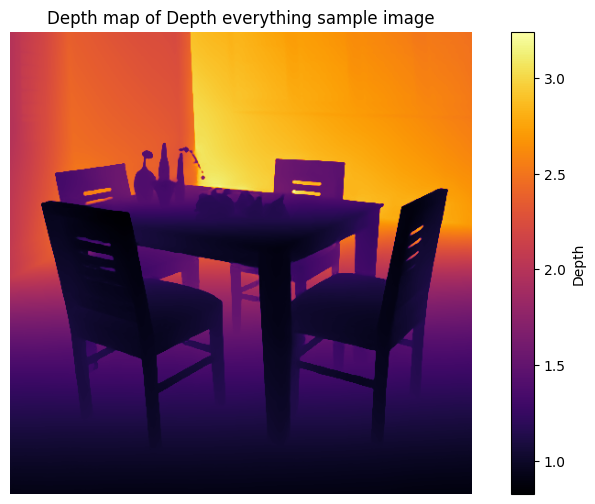

In [4]:
depth = prediction.depth[0] #image from the list

plt.figure(figsize=(10, 6))
plt.imshow(depth, cmap='inferno')
plt.colorbar(label='Depth')
plt.title('Depth map of Depth everything sample image')
plt.axis('off')
plt.show()

KITTI dataset is loaded into the memory for the further steps. Also, i set it to print out a bunch of data that is relevant and helpful for debugging when needed.

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((HEIGHT, WIDTH))
])

#DATASET IS LOADED AND DATALOADER IS CREATED

kitty_dataset =torchvision.datasets.Kitti(root="../datasets/", train=True,transform=transform, download=True)
kittty_dataloader = torch.utils.data.DataLoader(
    kitty_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    collate_fn=collate_fn, 
    num_workers=NUM_WORKERS,
    pin_memory=True
)

KITTY_LENGTH = len(kitty_dataset)
BATCH_COUNT = KITTY_LENGTH // BATCH_SIZE + (KITTY_LENGTH % BATCH_SIZE > 0)
print(f"KITTY dataset is length: {KITTY_LENGTH}\nDataloader has length: {len(kittty_dataloader)}\nBatch count {BATCH_COUNT}")

#I try a single batch to analyze the data structure and types
images, targets_batch = next(iter(kittty_dataloader))
print(f"Type of the images data is: {type(images)} type of image {type(images[0])} len: {len(images)} and type of the target is {type(targets_batch)} of len {len(targets_batch)}")

KITTY dataset is length: 7481
Dataloader has length: 1871
Batch count 1871
Type of the images data is: <class 'list'> type of image <class 'torch.Tensor'> len: 4 and type of the target is <class 'list'> of len 4


These functions are used to extract info from each batch of images and also to actually gather all that info and pass as outputs. This is needed in order to gather the input arrays for training. Namely, we need 2 versions of mean, median and max values of each crop as well as the x1,y1,x2,y2 coordinates of each box.

I however, feel conflicated about using coordinates as it feels not very generalizable when using data from other datasets or higher or lower resolution cameras that exist out there.

In [6]:
def extract_crops_depth(images_batch, targets_batch):
    # 1 IMAGES
    stacked_images = torch.stack(images_batch)
    image_list = [
        (img.permute(1,2,0).cpu().numpy() * 255).clip(0, 255).astype(np.uint8)
        for img in images_batch
    ]
    stacked_depths = depthAnything3.inference(image_list).depth
    depths_h = stacked_depths.shape[1]
    depths_w = stacked_depths.shape[2]

    img_h = stacked_images.shape[2]
    img_w = stacked_images.shape[3]

    x_scaling = depths_w/img_w
    y_scaling = depths_h/img_h

    print(f"Depths dim: (H,W): ({depths_h},{depths_w}) img: ({img_h}, {img_w}) type of images is {type(stacked_depths)} {type(stacked_depths[0])}")
    # 2,3 BOXES and DEPTHS
    boxes =[]
    depths = []
    skip = []
    image_indicies = set(range(len(images_batch)))
    keep=[]
    for i, targets in enumerate(targets_batch):
        boxes_with_target = [torch.tensor(target["bbox"], dtype=torch.int32) for target in targets if target["type"] in TARGET_TYPES]
        depths_with_target = [target["location"][2] for target in targets if target["type"] in TARGET_TYPES]
        if len(boxes_with_target) > 0:
            boxes.append(torch.stack(boxes_with_target))
            depths.append(torch.Tensor(depths_with_target))
        else:
            skip.append(i)

    # 3.5 check that there is actually data 
    if len(boxes) == 0:
        print("No boxes found in this batch, skipping...")
        del boxes, images_batch, targets_batch
        gc.collect()
        return -1, -1, -1,-1,-1,-1

    #3.6 skip images that we do not want and add the depths
    keep = list(image_indicies - set(skip))
    stacked_depths = stacked_depths[keep,:,:]
    depths = torch.cat(depths).cpu()

    
    # 4 crop the images to a specific size
    depths_mean =[]
    depths_median = []
    depths_max = []
    depths_mean_cut =[]
    for i in range(stacked_depths.shape[0]):
        # the current data is fetched
        image = stacked_depths[i]
        boxes_cur = boxes[i]

        #images are copped to the box
        for box in boxes_cur:
            x1,y1,x2,y2 = box.tolist()
            x1 = int(x1*x_scaling)
            x2 = int(x2*x_scaling)
            y1 = int(y1*y_scaling)
            y2 = int(y2*y_scaling)
            
            crop_np = image[y1:y2, x1:x2]

            if crop_np.size!=0:
                depths_mean.append(crop_np.mean().item())
                depths_median.append(np.median(crop_np).item())
                depths_max.append(crop_np.max().item())
                depths_mean_cut.append(
                    stats.trim_mean(
                        a=crop_np.flatten(),
                        proportiontocut=0.1,
                        nan_policy = "omit"
                        ).item()
                )
            else: 
                depths_mean.append(np.nan)
                depths_median.append(np.nan)
                depths_max.append(np.nan)
                depths_mean_cut.append(np.nan)
            #print(f"crop mean is {crop_np.nanmean()}")
            #print(f"x1: {x1}, x2 {x2}, y1 {y1}, y2 {y2}")
            del crop_np

    #exit function and clear the local variables
    del stacked_images, images_batch, targets_batch
    return boxes, depths.tolist(), depths_mean, depths_median, depths_max, depths_mean_cut

def extract_crops(loader: DataLoader):
    """
    Extract the crops before the embeddings are retrieved.

    Args:
        loader: dataloader for the dataset
    """
    depths_true_all = []
    depths_mean_all = []
    depths_median_all = []
    depths_max_all = []
    depths_mean_cut_all = []
    box_xyxy_all = []
    counter = 0
    
    for images_batch, targets_batch in loader:
        #preporcess the data, format it in a way that is expected by the model===================
        clear_output(wait=True)
        print(f"Batch {counter} in progress; ({counter/len(loader)*100:.2f}%);")

        #extract boxes and depths to be added and saved==========================================
        boxes, depths, depths_mean, depths_median, depths_max, depths_mean_cut = extract_crops_depth(images_batch, targets_batch)
        if depths_mean==-1:
            continue
        depths_true_all.extend(depths)
        depths_mean_all.extend(depths_mean)
        depths_median_all.extend(depths_median)
        depths_max_all.extend(depths_max)
        box_xyxy_all.extend(boxes)
        depths_mean_cut_all.extend(depths_mean_cut)

        #clear the variables and incremenet the counter===========================================
        del depths, depths_mean, depths_median, depths_max, boxes
        counter+=1

    gc.collect() 
    clear_output(wait=True)
    print("The means were successfully extracted 100%")
    return box_xyxy_all, depths_true_all, depths_mean_all, depths_median_all, depths_max_all, depths_mean_cut_all

In [7]:
extract_time_start = time.time()
boxes, depths_true, depths_mean, depths_median, depths_max, depths_mean_cut = extract_crops(kittty_dataloader)

The means were successfully extracted 100%


Here I format the lists of values to numpy arrays and store the results into a dataframe for further processing.

On important note, since the results of crops might be empty and return a nan value we need to apply a mask to all inputs to make sure there are no nan values in any column.

In [8]:
loss_fn = nn.L1Loss()

data = pd.DataFrame()

#convert everyhting to numpy
depths_mean_np = np.array(depths_mean)
depths_true_np = np.array(depths_true)
depths_median_np = np.array(depths_median)
depths_max_np = np.array(depths_max)
depths_mean_cut_np = np.array(depths_mean_cut)

#create a mask
mask = ~np.isnan(depths_mean_np) & ~np.isnan(depths_true_np) & ~np.isnan(depths_median_np) & ~np.isnan(depths_max_np) & ~np.isnan(depths_mean_cut_np)

#filter according to the mask
depths_mean_clean = depths_mean_np[mask]
depths_true_clean = depths_true_np[mask]
depths_median_clean = depths_median_np[mask]
depths_max_clean = depths_max_np[mask]
depths_mean_cut_clean = depths_mean_cut_np[mask]

print(f"nan count is {np.sum(~mask)}/ len {len(depths_mean_np)}\n")
mae_mean = loss_fn(torch.tensor(depths_mean_clean), torch.tensor(depths_true_clean))
mae_median = loss_fn(torch.tensor(depths_median_clean), torch.tensor(depths_true_clean))
mae_max = loss_fn(torch.tensor(depths_max_clean), torch.tensor(depths_true_clean))
mae_mean_cut = loss_fn(torch.tensor(depths_mean_cut_clean), torch.tensor(depths_true_clean))
print(f"MAE loss is:\nMean: {mae_mean} m\nMedian: {mae_median}\nMax: {mae_max} m\nMean cut: {mae_mean_cut}")

data["mean"]=depths_mean_clean
data["median"]=depths_median_clean
data["max"]=depths_max_clean
data["truth"]=depths_true_clean
data["mean_cute"]=depths_mean_cut_clean

nan count is 2/ len 28742

MAE loss is:
Mean: 4.134060759264807 m
Median: 4.447691282254586
Max: 30.484934063657093 m
Mean cut: 4.026720890483677


In [9]:
print(f"boxes type {type(boxes)} and len={len(boxes)} type of first element {type(boxes[0])}")

boxes_cat = torch.cat(boxes)
print(f"shape of stack is {boxes_cat.shape}")

x1 = boxes_cat[:, 0].numpy()[mask]
y1 = boxes_cat[:, 1].numpy()[mask]
x2 = boxes_cat[:, 2].numpy()[mask]
y2 = boxes_cat[:, 3].numpy()[mask]

data["x1"]=x1
data["y1"]=y1
data["x2"]=x2
data["y2"]=y2

data["width"]=data["x2"]-data["x1"]
data["height"]=data["y2"]-data["y1"]

extract_time_end = time.time()
extract_time = extract_time_end-extract_time_start

boxes type <class 'list'> and len=6684 type of first element <class 'torch.Tensor'>
shape of stack is torch.Size([28742, 4])


In [10]:
# I save data. This is relevant to avoid running the entire file each time and be able to retrieve the data from disk instead of relying on RAM
data.to_csv("../data/depths_de_all.csv", index=False)

## Training based on extracted data

If you only want to train based on the extracted data stored in a file. Then you should run the top most cell to import the libraries and then run all the cells below to perform the training.

Based on the paper the best performing model was chosen namely xgbregressor.

In [11]:
data = pd.read_csv("../data/depths_de_all.csv")

target = ["truth"]
features = list(set(data.columns)-set(target))

print(f"features: {features}\ntarget: {target}")

data.describe()

features: ['x1', 'y1', 'y2', 'height', 'mean', 'mean_cute', 'x2', 'width', 'max', 'median']
target: ['truth']


,mean,median,max,truth,mean_cute,x1,y1,x2,y2,width,height
count,28740.000000,28740.000000,28740.000000,28740.000000,28740.000000,28740.000000,28740.000000,28740.000000,28740.000000,28740.000000,28740.000000
mean,27.327447,24.294898,58.147098,28.014501,25.756420,488.478532,179.068511,600.419624,245.229819,111.941093,66.161308
std,16.101733,15.504012,26.227761,16.320222,15.990280,270.961410,12.299973,269.700610,53.407595,90.065780,50.166162
min,2.737485,2.077863,3.120853,-0.180000,2.728934,0.000000,39.000000,14.000000,140.000000,4.000000,12.000000
25%,14.518509,12.198030,38.192440,15.187500,13.086725,311.000000,174.000000,427.000000,208.000000,46.000000,31.000000
50%,24.425329,21.424607,55.196632,25.430000,22.736929,515.000000,179.000000,562.000000,226.000000,80.000000,47.000000
75%,37.010764,32.942643,74.839796,38.330002,35.088399,668.000000,185.000000,737.000000,264.000000,148.000000,83.000000
max,104.554253,105.731918,160.987000,86.180000,105.309410,1237.000000,276.000000,1241.000000,375.000000,581.000000,335.000000


Initialize the test and trainining data by splitting the dataframe first column wise and then row wise.

The models are either without setting any hyperparameters or matching the ones in the paper as closely as possible. One thing I changed is specifying the random state and not specifying the learning rate for rfr(not present in this implementation ig)

In [12]:
X_data = data[features]
y_data = data[target]

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

# Initialize the XGBoost
xgb_model = XGBRegressor(
    colsample_bytree=0.9,
    gamma=0.3,
    learning_rate=0.01, 
    max_depth=9,
    min_child_weight=3,
    n_estimators=1000, 
    reg_alpha=1,
    reg_lambda=0.9,
    subsample=0.7,
    random_state=42
)

xgb_model_raw = XGBRegressor(random_state=42)

# Initialize the random forest
rfr = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    max_features=2,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

rfr_raw = RandomForestRegressor(random_state=42)

Training the models all at once. Takes around 1 min to complete

In [13]:
xgb_model.fit(X_train, y_train)
print("Finishes training xgb paper like model")
xgb_model_raw.fit(X_train, y_train)
print("Finished training xgb raw model")
rfr.fit(X_train, y_train)
print("Finished training rfr paper like model")
rfr_raw.fit(X_train, y_train)
print("Finished training rfr raw model")

Finishes training xgb paper like model
Finished training xgb raw model
Finished training rfr paper like model
Finished training rfr raw model


Here MAE scores are printed to compare all the models between one another. Generally all of them performed not good and actually worse than any of the inputs without any training which is surprising.

In [14]:
loss_fn = nn.L1Loss()

models = [xgb_model, xgb_model_raw, rfr, rfr_raw]
models_labels = ["XGBosst regressor paper like", "XGBosst regressor", "Random foresr regressor paper","Random forest regressor"]

for model, label in zip(models, models_labels):
    y_predict_test = model.predict(X_test)
    y_predict_train  = model.predict(X_train)

    #print(f"datatype of y_predict is {type(y_predict_test)} data type of y_test is {type(y_test.values)}")

    mae_test = loss_fn(torch.from_numpy(y_predict_test), torch.from_numpy(y_test.values))
    mae_train = loss_fn(torch.from_numpy(y_predict_train), torch.from_numpy(y_train.values))

    print(f"MAE error of {label} on test data is {mae_test} m\nMAE error of {label} on train data is {mae_train} m\n")

MAE error of XGBosst regressor paper like on test data is 18.393991374245843 m
MAE error of XGBosst regressor paper like on train data is 18.262001020169027 m

MAE error of XGBosst regressor on test data is 18.402643851815913 m
MAE error of XGBosst regressor on train data is 18.26226237105351 m

MAE error of Random foresr regressor paper on test data is 18.35511457955914 m
MAE error of Random foresr regressor paper on train data is 18.25140635734311 m

MAE error of Random forest regressor on test data is 18.395217770126827 m
MAE error of Random forest regressor on train data is 18.26924348396031 m



## Time measurement of inference of the entire dataset

Here I measure how much time it took to inference on the entire dataset and divide by the number of images.

In [16]:
for model, label in zip(models, models_labels):
    start = time.time()
    y_predict = model.predict(X_data)
    end = time.time()

    inf_time = (end-start+extract_time)/KITTY_LENGTH
    print(f"Avg time to inference depth on an image with {label} is {inf_time}")

Avg time to inference depth on an image with XGBosst regressor paper like is 0.10312661164075579
Avg time to inference depth on an image with XGBosst regressor is 0.10312006049990542
Avg time to inference depth on an image with Random foresr regressor paper is 0.10333687528348387
Avg time to inference depth on an image with Random forest regressor is 0.10316532360266084
